### 1. Dependencies

In [1]:

import pandas as pd

import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import low_high, set_first_row_to_zero
from functions.portfolio_strategy_design.univariate_sorting_preprocess import prepare_univariate_sorting_inputs, prepare_esg_universe_sorting_inputs
from functions.data_functions.get_data import get_row_universe, get_usa_universe,get_japan_universe, get_processed_fx_rates, get_snp_esg_merge_to_universe, get_refinitive_snp_merge_to_universe, get_msci_esg_merge_to_universe, get_famafrench_factors, get_processed_index, get_accounting_data, get_gics_by_gvkey
from functions.data_functions.process_data import process_row_universe, process_usa_universe, process_global_universe, process_japan_universe, convert_factors_to_jpy
from functions.data_functions.ESG_coverage import build_esg_lookup, coverage_sample1_lc, coverage_sample2_returns, esg_coverage_table, firms_with_esg_data_by_year


In [2]:
#Important Filters
#############################################################

golden_data = "v_2C"

region_analysis = "Japan"


# Factor numeraire toggle (ONLY affects region_analysis == "Japan")
fama_factors_currency = "JPY"   # "USD" = US investor; "JPY" = Japanese investor
RF_JAPAN_PATH = "./data/FAMA/Rf_Japan_Monthly.xlsx"   # Japanese monthly T-bill (used when JPY)



# Signal Characterization
action_characterization = "4_signals_new" #"dict_all_SDG_1D_prosperity_into_people, 4_stakeholder_new" # "original_matteo" # "Moji_5_signals", , dict_all_SDG_1D


start_year = 2012  # these ESG sources are aligned for `start_year==2013`
end_year = 2024

#Univariate Sorting Percentile Split number
no_simple_quantiles = 7


ff_factors_number = 5

# ESG Variables
esg_choice = "msci"
esg_full_universe = True   # ESG sort on the FULL Compustat universe (no LC merge): chosen ESG provider as the SOLE signal (set True + a provider esg_choice to run)
esg_min_group_size = 5   # drop (year, currency, GICS) groups with fewer than this many names
drop_real_estate_Full_ESG = True   # ESG-only: drop Real Estate before map_sectors (else folded into 'Financial')
drop_utilities_Full_ESG = True     # ESG-only: drop Utilities from the ESG universe
download_gics_data = False   # re-pull GICS from WRDS (False = read cached ./data/GICS/ csv)

signal_denominator = "Sum_All_Signals" #"Sum_All_Signals" #"Sum_All_Initiatives"


if esg_choice == "refinitiv":
    start_year = 2014 #USA this is 2015
    end_year = 2024

if esg_choice == "msci":
    start_year = 2015
    end_year = 2024


##############################


# Other Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

add_accounting_data = False

industry_level = 0 # 0 = map to larger groups, 1 = GICS_level_1, 2 = GICS_level_2

japan_year_adjustment_split_month_for_two_or_one = 3

execute_3_filters = True
min_available_fyears = 3 #was 3
min_initatives_annual_reports = 5 #was 5
drop_suspicious_gvkeys = True

#Other Initalising variables Sector Analysis
drop_real_estate = True
drop_fin = False
drop_utilities = True

drop_health_care = False
anlayse_fashion_only = False
# Keep below as weighted_average_score 
msci_score_column = "weighted"   # MSCI score column: "industry" (industry_adjusted_score) or "weighted" (weighted_average_score)


#sector split
top_x_by_industry_even_split = 6

#Filtering the GOLDEN data equally top and bottom
use_alpha_bound = True

show_sector_portfolio =  False
show_sample_portfolio = False
plot_coverage = False
show_esg_coverage = False   # gated ESG-coverage diagnostic at notebook end



# Long-short spread per signal. Key = signal to build a spread for; value = direction.
#   "high_minus_low" -> long top quantile (p_n), short bottom (p_1)
#   "low_minus_high" -> long bottom (p_1), short top (p_n)
# Works for any key in `signal_quantiles` (signal_0.. and, when esg_choice is set,
# esg_refinitive / esg_sp / esg_msci). Empty dict {} = no spreads.
hml_directions = {
    "signal_0": "high_minus_low",
    "signal_1": "high_minus_low",
    "signal_2": "high_minus_low",
    "signal_3": "high_minus_low",
}






fama_factor_region = "Developed"
currency_filter = None
convert_to_USD = True


if region_analysis == "United_States":
    currency_filter = ['USD']
    region_filter = ["United States and Canada"]
    execute_region_filters = True
    convert_to_USD = False
    fama_factor_region = "United_States"
    



elif region_analysis == "North_America_and_Canada":
    currency_filter = ['USD'] 
    region_filter = ["United States and Canada"]
    execute_region_filters = True #If this is false there is rediculouly high alpha as it includes Irland and swiss
    convert_to_USD = False
    fama_factor_region = "North_America_and_Canada"
  


elif region_analysis == "Europe_and_North_America":
    #currencies we keep
    currency_filter = ['EUR', 'USD'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    
    


    

elif region_analysis == "Europe_and_North_America_and_Japan":
    #currencies we keep
    currency_filter = ['EUR', 'USD', 'JPY'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    
    #check JPY currency conversion (Might need to invert it)
    
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    


    

elif region_analysis == "Europe":
    currency_filter = ['EUR'] #"None" for uk
    region_filter = ["Europe"]
    execute_region_filters = True 
    #Keep in local currency
    #If we dont filter by EUR
    convert_to_USD = True    #True if UK
    fama_factor_region = "Europe"
  

elif region_analysis == "Japan":
    currency_filter = ['JPY'] 
    region_filter = ["Asia-Pacific"]
    execute_region_filters = True 
    #Keep portfolios in local currency (yen) when fama_factors_currency == "JPY" (Ei convert to USD is False)
    convert_to_USD = (fama_factors_currency == "USD")
    fama_factor_region = "Japan"

In [3]:
#Golden Dataset Location
from pathlib import Path
import os

golden_location = Path(
    os.environ.get(
        "GOLDEN_LOCATION",
        Path.home() / "Documents" / "GitHub" / "data" / "Golden_Data",
    )
)

# Golden Dataset
if golden_data == "v_2C":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2C_20260512.csv")
elif golden_data == "v_2B3":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2B3_20260511.csv")
elif golden_data == "v_2A":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2A.csv")
elif golden_data == "v_2B1":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2B1_20260409.csv")




# 1. Parameters 

In [4]:
# --- Parameter summary (prints below the cell) ---
from functions.output_paths import RUN_PARAM_NAMES, format_run_parameters

_run_parameters_text = format_run_parameters(globals(), RUN_PARAM_NAMES)
print(_run_parameters_text)


=== Run parameters ===
region_analysis              = 'Japan'
action_characterization      = '4_signals_new'
no_simple_quantiles          = 7
execute_3_filters            = True
golden_data                  = 'v_2C'
signal_denominator           = 'Sum_All_Signals'
esg_choice                   = 'msci'
start_year                   = 2015
end_year                     = 2024
fama_factor_region           = 'Japan'
ff_factors_number            = 5
currency_filter              = ['JPY']
convert_to_USD               = False
drop_real_estate             = True
use_alpha_bound              = True
show_sector_portfolio        = False
industry_level               = 0
min_available_fyears         = 3
top_x_by_industry_even_split = 6
alpha_bound                  = 0.1
mktcap_covered               = 0.95



Signal Design

In [5]:
from functions.signal_design.signal_definitions import dict_all_SDG_1D, dict_2d_actions_stakeholders_original_matteo,dict_4_signals_Action_1D_Pre_Nikkei, dict_4_stakeholder_signals_Pre_Nikkei, dict_all_SDG_1D_prosperity_into_people

#Choose which action characterization to use, which is dependent on function

#categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()

if action_characterization == "original_matteo":
    categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()

    #What signals to include~~~
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
}



elif action_characterization == "4_signals_new":
    categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = dict_4_signals_Action_1D_Pre_Nikkei()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
        "signal_3": signal_3_name,
    }


elif action_characterization == "4_stakeholder_new":
    categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = dict_4_stakeholder_signals_Pre_Nikkei()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
        "signal_3": signal_3_name,
    }


elif action_characterization == "dict_all_SDG_1D":
    categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
    }

elif action_characterization == "dict_all_SDG_1D_prosperity_into_people":
    categories_dict, signal_0_name, signal_1_name = dict_all_SDG_1D_prosperity_into_people()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
    }

if esg_full_universe:
    # ESG on the full Compustat universe: make the chosen ESG provider the sole signal.
    if esg_choice == "none":
        raise ValueError("esg_full_universe=True requires esg_choice in {'msci','refinitiv','s&p'} (not 'none').")
    lc_signals = {}
    show_sector_portfolio = False   # sector portfolio is pinned to signal_2, which will not exist
    hml_directions = {}             # cleared here; cell 11 re-adds the ESG long-short key


Signal Choice

### 2. Data

In [6]:

analyse_high_low = "High"
_bucket = "high" if analyse_high_low == "High" else "low"
_all_lc_signals = [(f"signal_{i}", _bucket) for i in range(len(lc_signals))]

if esg_choice == "none":

    universe_signals = {}
    analysis_selection = _all_lc_signals



elif esg_choice == "refinitiv":
    universe_signals = {"esg_refinitive": "esg_refinitive",}
    analysis_selection = _all_lc_signals + [("esg_refinitive", "high")]
    hml_directions["esg_refinitive"] = ["high_minus_low"]
    
elif esg_choice == "s&p":
    universe_signals = {    "esg_sp": "esg_sp",}
    analysis_selection = [("esg_sp", "high"), ("esg_sp", "low")] + _all_lc_signals
    hml_directions["esg_sp"] =  ["high_minus_low"]
elif esg_choice == "msci":
    universe_signals = {"esg_msci": "esg_msci",}
    analysis_selection = _all_lc_signals + [("esg_msci", "high")]
    hml_directions["esg_msci"] = ["high_minus_low"]


#### 2.1 LC dataset

clean below

In [7]:
from functions.data_functions.process_lc import process_lc, map_sectors, filter_sum_activities_by_fiscal_year_quantiles

lc = process_lc(lc, start_year, end_year)

# raw LC snapshot (pre sample-filters) for the ESG-coverage diagnostic
if show_esg_coverage:
    lc_raw_for_coverage = lc.copy()




# Additional Filters!



if execute_3_filters:
    #1-------------Filter companies with less than 3 years of data


    from functions.data_functions.process_lc import add_available_fyears
    lc = add_available_fyears(lc)

    print(f"Before filtering companies with less than {min_available_fyears} years of data: ", lc.shape)
    lc = lc[lc["n_available_fyears"] >= min_available_fyears]
    print(f"After filtering companies with less than {min_available_fyears} years of data: ", lc.shape)



    #2-------------Filter out suspicious gvkeys

    if drop_suspicious_gvkeys:
        print("Shape before: ", lc.shape)

        lc_suspicious = pd.read_csv(golden_location / "lc_gvkey_suspicious.csv")

        print("Number of suspicious: ", lc_suspicious.shape[0])
        print(lc_suspicious["suspicious_flag"].value_counts())

        lc_suspicious["original_gvkey"] = lc_suspicious["original_gvkey"].astype(str).str.zfill(6)
        lc["gvkey"] = lc["gvkey"].astype(str).str.zfill(6)
        print("Number of suspicious that are NAN: ", lc_suspicious["suspicious_flag"].isna().sum())

        print("unique gvkeys: ", lc["gvkey"].nunique(), "Unique gvkeys in suspicious: ", lc_suspicious["original_gvkey"].nunique())
        lc = lc.merge(lc_suspicious[["original_gvkey", "suspicious_flag", "likely_reason_codes"]], left_on="gvkey", right_on="original_gvkey", how="left")
        print(lc["suspicious_flag"].value_counts())
        print("Number of suspicious that are NAN: ", lc["suspicious_flag"].isna().sum())
        lc.to_csv("./data/debug/lc_before_suspicious_filtered.csv")
        lc = lc[lc["suspicious_flag"] != True]
        print("Shape after filtering Truly Sus: ", lc.shape)


    #3-------------Filter out Annual Reports with Less tha 5 Total initaitves
    print("Before filtering Annual Reports: ", lc.shape)
    lc = lc[~((lc["n_predicted_initiatives"] < min_initatives_annual_reports) & (lc["report_type"] == "Annual Report"))]
    print("After filtering Annual Reports: ", lc.shape)



    lc.to_csv("./data/debug/lc_after_all_filter.csv")



if anlayse_fashion_only:
    lc = lc[lc['GICS_level_3'].isin(["Textiles, Apparel & Luxury Goods"])]



if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']




>>>> add_missing_gvkeys: filled 0 rows
Added SREC columns:  Index(['customers', 'employees', 'environment',
       'local communities and society', 'nothing', 'shareholders',
       'suppliers'],
      dtype='object')
Before filtering companies with less than 3 years of data:  (61788, 532)
After filtering companies with less than 3 years of data:  (52874, 532)
Shape before:  (52874, 532)
Number of suspicious:  17472
suspicious_flag
False    11929
True      5543
Name: count, dtype: int64
Number of suspicious that are NAN:  0
unique gvkeys:  9069 Unique gvkeys in suspicious:  17472
suspicious_flag
False    37737
True     14764
Name: count, dtype: int64
Number of suspicious that are NAN:  373
Shape after filtering Truly Sus:  (38110, 535)
Before filtering Annual Reports:  (38110, 535)
After filtering Annual Reports:  (35664, 535)


In [8]:


if industry_level == 0:
    lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)
elif industry_level == 1:
    lc['Industry'] = lc['GICS_level_1']
elif industry_level == 2:
    lc['Industry'] = lc['GICS_level_2']


if drop_fin:
    lc = lc[lc['Industry'] != 'Financial']

if drop_utilities:
    lc = lc[lc['Industry'] != 'Utilities']

if drop_health_care:
    lc = lc[lc['Industry'] != 'Health Care']

# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]


if execute_region_filters == True:
    lc = lc[lc["MacroRegion"].isin(region_filter)]
    if region_analysis == "United_States":
            lc = lc[lc["loc"] == "USA"]


In [9]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]

    else:
        lc[f'sum_with_{value}'] = lc[key].values



if signal_denominator == "Sum_All_Signals":
    lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)
elif signal_denominator == "Sum_All_Initiatives":
    lc['sum_activities'] = lc['n_predicted_initiatives']


In [10]:
lc["sum_activities"].describe()

count    15443.000000
mean        31.185780
std         33.272711
min          2.000000
25%         10.000000
50%         20.000000
75%         39.000000
max        369.000000
Name: sum_activities, dtype: float64

In [11]:
if use_alpha_bound:

    lc = filter_sum_activities_by_fiscal_year_quantiles(
        lc,
        lower_exclude= (alpha_bound/2),
        upper_exclude= (alpha_bound/2),
    )

else:
    lower_exclude = 0.2*2
    upper_exclude = 0.05*2

    lc = filter_sum_activities_by_fiscal_year_quantiles(
        lc,
        lower_exclude= (lower_exclude/2),
        upper_exclude= (upper_exclude/2),
    )

In [12]:
lc["sum_activities"].describe()

count    13553.000000
mean        27.343762
std         20.559955
min          5.000000
25%         12.000000
50%         21.000000
75%         36.000000
max        129.000000
Name: sum_activities, dtype: float64

Create the signal

In [13]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Num stocks in USA and EU prior to some more filters

In [14]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

0

#### 2.2 WRDS, Fama-French and FX data

Get and Process:
1- FX data

2- USA Universe

3- ROW Universe

4 - Japan

5 - ESG

4- Fama-French

5- Global Universe

6- Accounting Data

In [ ]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn
fx_rates = get_processed_fx_rates(end_year)

# Keep local-currency series for Europe/Japan analysis (no FX conversion)

usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)
usa_universe = process_usa_universe(usa_universe)

row_universe = get_row_universe(start_year, end_year, download_wrds_data=False)
row_universe = process_row_universe(row_universe,fx_rates,convert_to_USD,)


japan_universe = get_japan_universe(start_year, end_year, download_wrds_data=False)
japan_universe = process_japan_universe(japan_universe,fx_rates,convert_to_USD,japan_year_adjustment_split_month_for_two_or_one)

# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100
    japan_universe['esg'] = 100

elif esg_choice != 'none':
    if esg_choice == "refinitiv":
        usa_universe, row_universe, japan_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe, japan_universe)
    elif esg_choice == "s&p":
        usa_universe, row_universe, japan_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe, japan_universe)
    elif esg_choice == "msci":
        usa_universe, row_universe, japan_universe = get_msci_esg_merge_to_universe(usa_universe, row_universe, japan_universe, score_column=msci_score_column)

fama_french = get_famafrench_factors(
    start_year,
    end_year,
    fama_factor_region,
    ff_factors_number,
    download_developed_ff_data=False,
)

# Convert USD factors -> JPY numeraire for the Japanese-investor case
if region_analysis == "Japan" and fama_factors_currency == "JPY":
    fama_french = convert_factors_to_jpy(fama_french, fx_rates, RF_JAPAN_PATH)

global_universe = process_global_universe(usa_universe,row_universe,japan_universe,currency_filter,mktcap_covered,
    esg_choice,)

print("columns with year")
print([c for c in global_universe.columns if c == 'year' or c.startswith('year_')])

# if add_accounting_data:
#     #Note this will result in a lower sample and non-profitable stocks will be removed
#     global_universe = global_universe.drop(columns=['year_x'], errors='ignore')
#     global_universe = get_accounting_data(global_universe, region_analysis, start_year, end_year, dowload_acc_data = True)


#Ensure gvkey is 6 digits for merging
global_universe["gvkey"] = global_universe["gvkey"].astype(str).str.zfill(6)
lc["gvkey"] = lc["gvkey"].astype(str).str.zfill(6)

In [ ]:
lc["Industry"].unique()

array(['Industrials', 'Primary Industries', 'Health Care', 'Consumer',
       'ICT', 'Financial'], dtype=object)

### 3. Univariate Portfolio sorting

In [ ]:
cols_standardization = ['rfyear', 'curcdd', 'Industry']

if esg_full_universe:
    # Level 2: ESG on the FULL Compustat universe (no LC merge). GICS supplies the
    # industry classification for industry-neutral standardization.
    gics_by_gvkey = get_gics_by_gvkey(
        global_universe, region_analysis, end_year, download_gics_data=download_gics_data
    )
    prep = prepare_esg_universe_sorting_inputs(
        global_universe=global_universe,
        gics_by_gvkey=gics_by_gvkey,
        fama_french=fama_french,
        universe_signals=universe_signals,
        industry_level=industry_level,
        year_col="last_year",
        min_group_size=esg_min_group_size,
        drop_real_estate=drop_real_estate_Full_ESG,
        drop_utilities=drop_utilities_Full_ESG,
    )
else:
    prep = prepare_univariate_sorting_inputs(
        global_universe=global_universe,
        lc=lc,
        fama_french=fama_french,
        lc_signals=lc_signals,
        universe_signals=universe_signals,
        category_columns=sorted(categories_dict.keys()),
        cols_standardization=cols_standardization,
        apply_geo_filter=False,
    )

global_universe = prep.global_universe
global_returns  = prep.global_returns
signals         = prep.signals        # dict: column name -> (date x gvkey_iid) pivot
signal_names    = prep.signal_names   # dict: column name -> display name
signal_df       = prep.global_long_df
fama_french     = prep.fama_french


Read GICS CSV
[prepare_esg_universe] dropped 0 rows missing ['last_year', 'curcdd', 'Industry']
[prepare_esg_universe] dropped 0 firm-months in groups < 5 names (grouping on ['last_year', 'curcdd', 'Industry'])
[prepare_esg_universe] kept 120/144 return months covered by FF | FF rows=120
[prepare_esg_universe] FF<->returns month alignment proof (positional):
 row returns_month ff_month  match
   0       2015-01  2015-01   True
   1       2015-02  2015-02   True
   2       2015-03  2015-03   True
   3       2015-04  2015-04   True
   4       2015-05  2015-05   True
   5       2015-06  2015-06   True
   ... 
 row returns_month ff_month  match
 114       2024-07  2024-07   True
 115       2024-08  2024-08   True
 116       2024-09  2024-09   True
 117       2024-10  2024-10   True
 118       2024-11  2024-11   True
 119       2024-12  2024-12   True
   matched 120/120 rows | returns index monotonic-increasing=True
   -> every FF row sits on the same calendar month as its returns row. OK


# code to filter infinte stocks

In [ ]:
# FIND ANY STOCKS THAT HAVE INF VALUES  

import numpy as np

bad_columns = set()
for df in signals.values():
    # numeric only, in case of odd dtypes
    num = df.select_dtypes(include=[np.number])
    if num.empty:
        continue
    bad_columns.update(num.columns[np.isinf(num).any(axis=0)].tolist())

bad_columns = list(bad_columns)

print("gvekys dropped due to inf values:")
print(bad_columns)


# filter these infinite values

signals = {
    name: df.drop(columns=bad_columns, errors="ignore")
    for name, df in signals.items()
}

import numpy as np
if 'signal_0' in signals:
    fit1 = signals['signal_0'].select_dtypes(include=["float", "float64"])
    if np.isinf(fit1).sum().sum() > 0:
        print("There are inf values in the signal_0 column")

gvekys dropped due to inf values:
[]


% Nan in accounting data

In [ ]:
# if add_accounting_data:
#     #Amount of missing accounting data as a percent
#     cols = ["roa0","roa1","roa2","ros0","ros1","ros2","sales_intensity"]
#     print((100 * global_universe[cols].isna().mean()).sort_values(ascending=False))

In [ ]:
# MANUAL SETTINGS (for UnivariateQuantilePortfolio in the next section)
first_conditioning_set = 0       # momentum-like strategies: increase to skip early rows
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # if True, low / middle / high extremes only


#### 3.1 Univariate sorting

In [ ]:
from functions.portfolio_strategy_design.Univariate_Portfolio import UnivariateQuantilePortfolio

signal_quantiles: dict[str, pd.DataFrame] = {}
signal_quantile_constituents: dict[str, pd.Series] = {}

for col, pivot in signals.items():
    U = UnivariateQuantilePortfolio(
        signal=pivot,
        returns=global_returns,
        n_quantiles=no_simple_quantiles,
        first_conditioning_set=first_conditioning_set,
        take_extremes=take_extremes,
        n_extremes_quantiles=no_simple_extremes_quantiles,
    )
    signal_quantiles[col] = U.compute_returns()
    signal_quantile_constituents[col] = U.get_constituents_over_time()

# 4. Sector Split

In [ ]:
# Store constituents over time + compute “next-month return” by Industry


from functions.portfolio_strategy_design.Sector_Portfolio import SectorPortfolio


if show_sector_portfolio:
    # Sector portfolio is pinned to signal_2.
    global_signal_2 = signals["signal_2"]

    #Build an industry pivot aligned to global_returns  and global_signal_*
    global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

    #This will automatically split the even_split_no stocks into the unique sectors.
    #Select the n highest ranked stocks in each industruy and build portfolios using them.
    S = SectorPortfolio(
        signal=global_signal_2,
        returns=global_returns,
        global_universe=global_universe,
        sector_split=top_x_by_industry_even_split,          # fixed N per industry
        manual_input_split=False,
        first_conditioning_set=first_conditioning_set,
        ascending=False,
    )


    #all_industry_returns = S.compute_industry_returns()
    industry_constituents = S.get_constituents_over_time()   

    #Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!
    sector_portfolio_returns = S.equal_weight_mean_return() # equal-weight across industries


In [ ]:
# Add Market Portfolios
market_factor = fama_french["mktrf"]

file_path = "./data/MSCI/MSCI_World.xlsx"
MSCI = get_processed_index(file_path, global_returns) 

In [ ]:
# Transform in excess returns using the risk free rate

for col in signal_quantiles:
    signal_quantiles[col] = signal_quantiles[col].sub(fama_french['rf'].values, axis=0)

MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)

if show_sector_portfolio:
    sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)


Excess_returns_sample = (
    global_returns.mean(axis=1)
    .sub(fama_french["rf"].values, axis=0)
    .to_frame("Sample")
)

#no need for market_factor


In [ ]:
# Regression inputs keep their NaN first row (ff3_regressions drops it).
# Zeroed copies are ONLY for cumulative plots / compounding.
global_returns_cum = set_first_row_to_zero(global_returns)
signal_quantiles_cum = {c: set_first_row_to_zero(df) for c, df in signal_quantiles.items()}

market_factor_cum = market_factor.copy()   # .copy() avoids mutating fama_french["mktrf"]
market_factor_cum.iloc[0] = 0

if show_sector_portfolio:
    sector_portfolio_returns_cum = sector_portfolio_returns.copy()
    sector_portfolio_returns_cum.iloc[0] = 0

# 5. Fama-French

In [ ]:

if show_sector_portfolio:
    sector_portfolio_returns_df = pd.DataFrame()
    sector_portfolio_returns_df[f"Sector equal split {signal_2_name}"] = sector_portfolio_returns
    sector_portfolio_returns = sector_portfolio_returns_df

High - Low

In [ ]:
# Per-signal long-short spreads, driven by `hml_directions` (set in the parameters cell).
# Build two parallel dicts keyed by the generated spread label:
#   spread_signals[label] -> raw spread (NaN first row) for FF tables + rolling FF regression
#   spread_cum[label]     -> zeroed-first-row spread for cumulative compounding/plot
# Long-short spread: rf cancels ((high-rf) - (low-rf) = high - low), so rf is NOT added back.
_hml_hi, _hml_lo = f"p_{no_simple_quantiles}", "p_1"

spread_signals: dict[str, pd.DataFrame] = {}
spread_cum: dict[str, pd.Series] = {}

for _sig, _dirs in hml_directions.items():
    if _sig not in signal_quantiles:
        raise KeyError(
            f"{_sig!r} in hml_directions not found in signal_quantiles "
            f"(available: {list(signal_quantiles)})"
        )

    # A signal may map to a single direction (str) or several (list/tuple),
    # e.g. ["high_minus_low", "low_minus_high"] to build both spreads.
    for _dir in ([_dirs] if isinstance(_dirs, str) else _dirs):
        if _dir == "high_minus_low":
            _label = f"High - Low {signal_names[_sig]}"
            _raw = signal_quantiles[_sig][_hml_hi] - signal_quantiles[_sig][_hml_lo]
            _cum = signal_quantiles_cum[_sig][_hml_hi] - signal_quantiles_cum[_sig][_hml_lo]
        elif _dir == "low_minus_high":
            _label = f"Low - High {signal_names[_sig]}"
            _raw = signal_quantiles[_sig][_hml_lo] - signal_quantiles[_sig][_hml_hi]
            _cum = signal_quantiles_cum[_sig][_hml_lo] - signal_quantiles_cum[_sig][_hml_hi]
        else:
            raise ValueError(
                f"Unknown direction {_dir!r} for {_sig}; use 'high_minus_low' or 'low_minus_high'"
            )

        spread_signals[_label] = _raw.to_frame(_label)
        spread_cum[_label] = _cum


In [ ]:
#### Rolling Alpha
from functions.portfolio_metrics.fama_french import rolling_ff_alphas

# Select what you want to analyse in the rolling alpha and cumulative returns
base_analysis_selection = [(s, "high") for s in reversed(lc_signals)]
if not esg_full_universe:
    base_analysis_selection.append(("signal_0", "low"))
# base_analysis_selection.append(("signal_2", "high"))


# base_analysis_selection.remove(("signal_0", "high"))


if show_sector_portfolio:
    base_analysis_selection.append(("Sector equal split signal_2", "high"))




if esg_choice == "refinitiv":
   
    base_analysis_selection.append(("esg_refinitive", "high"))
elif esg_choice == "s&p":
    base_analysis_selection.append(("esg_sp", "high"))
elif esg_choice == "msci":
    base_analysis_selection.append(("esg_msci", "high"))
    


rolling_alpha_selection = base_analysis_selection

_valid_buckets = {"high", "low"}
_invalid_buckets = sorted({b for _, b in rolling_alpha_selection} - _valid_buckets)
if _invalid_buckets:
    raise ValueError(f"Invalid bucket(s) in analysis_selection: {_invalid_buckets}. Use 'high' or 'low'.")

_missing_signal_keys = sorted({c for c, _ in rolling_alpha_selection} - set(signal_quantiles))
if _missing_signal_keys:
    raise KeyError(f"Signal key(s) in analysis_selection not found in signal_quantiles: {_missing_signal_keys}")

_bucket_to_col    = {"high": f"p_{no_simple_quantiles}", "low": "p_1"}
_bucket_to_prefix = {"high": "High", "low": "Low"}

rolling_signals_arg = [
    {
        "label": f"{_bucket_to_prefix[bucket]} {signal_names[col]}",
        "returns": signal_quantiles[col],
        "alpha_column": _bucket_to_col[bucket],
    }
    for col, bucket in rolling_alpha_selection
]


if show_sector_portfolio:
    _sector_label = f"Sector equal split {signal_2_name}"
    rolling_signals_arg.append({
        "label": _sector_label,
        "returns": sector_portfolio_returns,
        "alpha_column": _sector_label,
    })

if show_sample_portfolio:
    _market_sample_label = f"Sample"
    rolling_signals_arg.append({
        "label": _market_sample_label,
        "returns": Excess_returns_sample,
        "alpha_column": _market_sample_label,
    })


for _label, _df in spread_signals.items():
    rolling_signals_arg.append({
        "label": _label,
        "returns": _df,
        "alpha_column": _label,
    })


try:
    rolling_alphas_window_size_40 = rolling_ff_alphas(
        signals=rolling_signals_arg,
        fama_french=fama_french,
        window_size=40,
        n_factors=ff_factors_number,
    )
except Exception as e:
    print(f"Error in rolling_ff_alphas: {e}")


rolling_alphas_window_size_24 = rolling_ff_alphas(
    signals=rolling_signals_arg,
    fama_french=fama_french,
    window_size=24,
    n_factors=ff_factors_number,
)




# 6. Performance Metrics

In [ ]:
global_gross_portfolio_returns = pd.DataFrame(index=global_returns_cum.index)
if show_sample_portfolio:
    global_gross_portfolio_returns['Sample'] = 1 + global_returns_cum.mean(axis=1).sub(fama_french["rf"].values, axis=0)


global_gross_portfolio_returns["Market"] = 1 + market_factor_cum 
# Single selection shared with rolling alpha.
portfolio_selection = base_analysis_selection

for col, bucket in portfolio_selection:
    quantile_col = _bucket_to_col[bucket]
    label        = f"{_bucket_to_prefix[bucket]} {signal_names[col]}"
    global_gross_portfolio_returns[label] = 1 + signal_quantiles_cum[col][quantile_col]


if show_sector_portfolio:
    _sector_col = f"Sector equal split {signal_2_name}"
    global_gross_portfolio_returns[_sector_col] = 1 + sector_portfolio_returns_cum[_sector_col]

#global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns

# Add risk free rate back for cumulative returns
non_risk_free_returns = global_gross_portfolio_returns.add(fama_french["rf"].values, axis=0)
portfolio_returns = non_risk_free_returns - 1

# Long-short spreads: rf cancels out ((high-rf) - (low-rf) = high - low),
# so append directly without adding rf back.
for _label, _series in spread_cum.items():
    portfolio_returns[_label] = _series

# Cumulative Returns Plot

In [ ]:
portfolio_returns.isna().sum()

Market                 0
High esg_msci          0
High - Low esg_msci    0
dtype: int64

In [ ]:
from functions.portfolio_metrics.fama_french import ff3_regressions, ff5_regressions, rolling_ff_alphas

# FF3 table: every signal plus the sector portfolio.
ff3_parts = [
    low_high(
        ff3_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
        signal_names[col],
    )
    for col in signal_quantiles
]

take_high_minus_low = True
if take_high_minus_low:
    for _label, _df in spread_signals.items():
        ff3_parts.append(ff3_regressions(_df, fama_french.reset_index(drop=True)))

if show_sector_portfolio:
    ff3_parts.append(ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))

if show_sample_portfolio:
    ff3_parts.append(ff3_regressions(Excess_returns_sample, fama_french.reset_index(drop=True)))

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
#ff3_parts_df.to_csv('./output/ff3_' + _{start_date}-{end_date} + '.csv')
ff3_parts_df.head()

,Low esg_msci,High esg_msci,High - Low esg_msci
alpha,-0.01,0.01,0.02
beta_mkt,0.97,1.13,0.16
beta_smb,0.32,0.04,-0.28
beta_hml,0.10,0.12,0.02
p-value(alpha),0.90,0.93,0.86


In [ ]:
from functions.portfolio_metrics.fama_french import ff3_regressions, ff5_regressions, rolling_ff_alphas

ff5_parts = [
        low_high(
            ff5_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
            signal_names[col],
        )
        for col in signal_quantiles
    ]


take_high_minus_low = True
if take_high_minus_low:
    for _label, _df in spread_signals.items():
        ff5_parts.append(ff5_regressions(_df, fama_french.reset_index(drop=True)))

if show_sector_portfolio:
        ff5_parts.append(ff5_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))

if show_sample_portfolio:
        ff5_parts.append(ff5_regressions(Excess_returns_sample, fama_french.reset_index(drop=True)))

ff5_parts_df = pd.concat(ff5_parts, axis=1).round(2)
    #ff5_parts_df.to_csv('./output/ff5_' + _{start_date}-{end_date} + '.csv')

ff5_parts_df.head(7)

,Low esg_msci,High esg_msci,High - Low esg_msci
alpha,-0.04,-0.01,0.03
beta_mkt,0.99,1.09,0.10
beta_smb,0.31,0.09,-0.21
beta_hml,0.10,0.31,0.21
beta_rmw,0.10,0.19,0.09
beta_cma,0.12,-0.27,-0.39
p-value(alpha),0.74,0.94,0.82


In [ ]:
# --- Sweep harness: persist FF tables when running under papermill ---
# No-op during normal interactive runs (sweep_mode defaults to False).
if globals().get("sweep_mode", False):
    import os, pickle
    _sweep_out = globals().get("sweep_out_dir", "./output/SWEEP")
    os.makedirs(_sweep_out, exist_ok=True)
    _rid = str(globals().get("sweep_run_id", "run"))
    _payload = {"ff3": ff3_parts_df, "ff5": ff5_parts_df}
    _fp = os.path.join(_sweep_out, f"ff_{_rid}.pkl")
    with open(_fp, "wb") as _f:
        pickle.dump(_payload, _f)
    print(f"[sweep] saved FF tables for run {_rid} -> {_fp}")


Saving run artifacts to: output/4_signals_new/Japan/Sum_All_Signals/esg/msci_esg/with_filters/2015-01-2024-12_split7


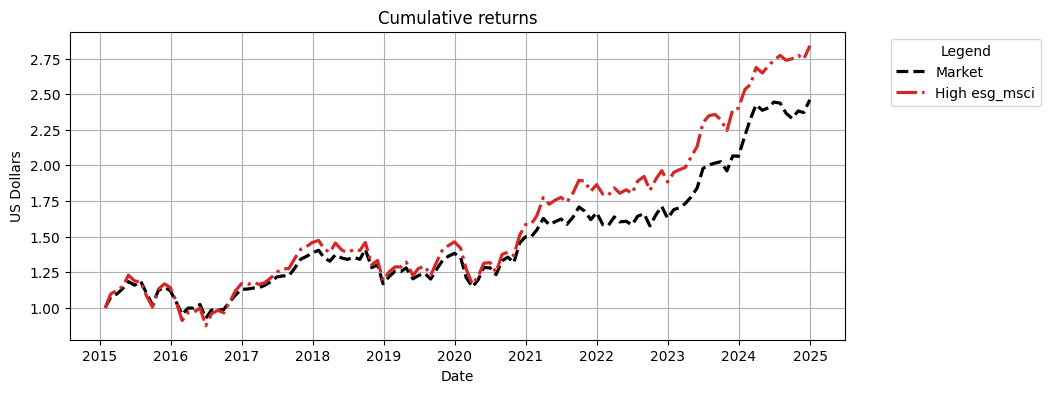

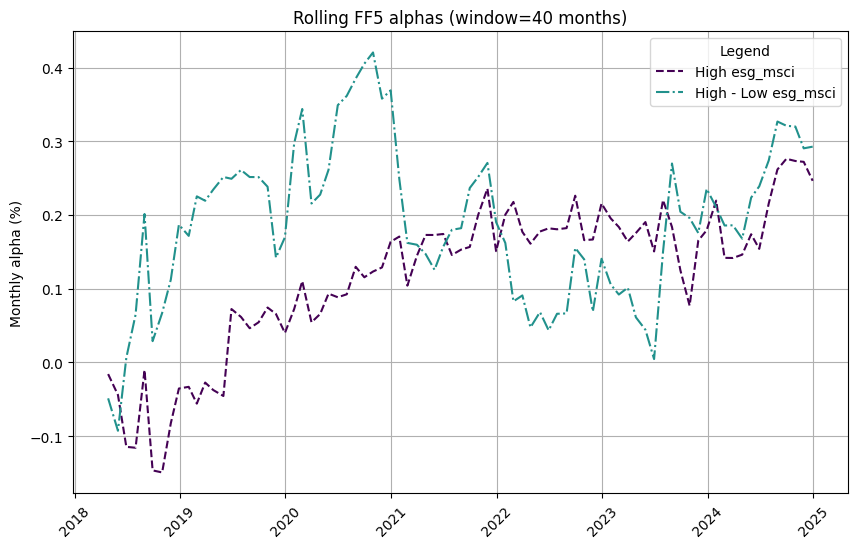

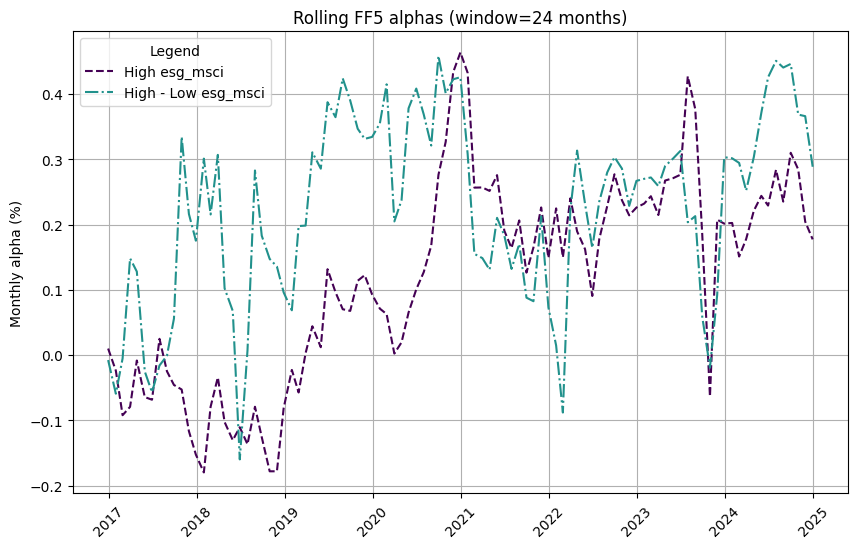

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,3.77%,5.61%,19.24%,19.24%,47.48%,78.05%,146.03%,146.03%
High esg_msci,3.45%,3.34%,18.30%,18.30%,52.30%,94.17%,184.02%,184.02%
High - Low esg_msci,0.20%,-1.31%,0.76%,0.76%,-1.64%,9.18%,20.46%,20.46%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Market,0.71,-10.10%,-21.97%,,
High esg_msci,0.72,-12.19%,-28.87%,-0.01,0.940
High - Low esg_msci,0.35,-3.80%,-11.02%,0.03,0.820


In [ ]:
import importlib
import functions.output_paths as output_paths_module
importlib.reload(output_paths_module)

from functions.portfolio_metrics.Strategy_Perfomance import StrategyPerformance
from functions.portfolio_metrics.fama_french import plot_rolling_alpha_function
from functions.output_paths import (
    output_csv_dir,
    output_images_dir,
    output_images_other_dir,
    output_run_dir,
    save_run_parameters,
)


start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

_run_dir = output_run_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
_csv_dir = output_csv_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
_img_dir = output_images_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
_other_img_dir = output_images_other_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
print(f"Saving run artifacts to: {_run_dir}")

save_run_parameters(_run_dir / "parameters.txt", globals())

ff_parts_df = ff3_parts_df if ff_factors_number == 3 else ff5_parts_df

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff_parts_df)

_ff = fama_factor_region

_csv_dir.mkdir(parents=True, exist_ok=True)
ff_parts_df.to_csv(_csv_dir / f"ff{ff_factors_number}_regressions_ff-{_ff}.csv")

cumulative_table = sp.cumulative_performance_table(
    csv_path=_csv_dir / f"strategy_cumulative_performance_ff-{_ff}.csv")

risk_table = sp.performance_risk_metrics_table(
    csv_path=_csv_dir / f"strategy_performance_metrics_ff-{_ff}.csv")

# Two separate cumulative-returns plots. The long-short (High - Low / Low - High)
# spreads stay in `sp.portfolio_returns`, so the cumulative table, risk table,
# regressions and rolling alphas are unaffected by how we split the plots.
_spread_cols = [c for c in spread_cum if c in portfolio_returns.columns]

# (1) Long portfolios only (spreads dropped); keeps Market / Sample benchmarks.
_long_only = portfolio_returns.drop(columns=_spread_cols, errors="ignore")
sp.plot_cumulative_returns(
    portfolio_returns=_long_only,
    title="Cumulative returns - long portfolios",
    tight_layout_rect = (0, 5, 100, 0.9),
    save_path=_img_dir / f"cumulative_returns_long_ff-{_ff}.png",
    csv_path=_csv_dir / f"gross_cumulative_returns_long_ff-{_ff}.csv",
)

# (2) High-low spreads only -- drawn only when at least one high-low signal exists.
if _spread_cols:
    sp.plot_cumulative_returns(
        portfolio_returns=portfolio_returns[_spread_cols],
        title="Cumulative returns - high-low spreads",
        tight_layout_rect = (0, 5, 100, 0.9),
        save_path=_img_dir / f"cumulative_returns_highlow_ff-{_ff}.png",
        csv_path=_csv_dir / f"gross_cumulative_returns_highlow_ff-{_ff}.csv",
    )
else:
    print("[plot] no high-low spreads (hml_directions empty) -> skipping spread plot")


# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
try:
    plot_rolling_alpha_function(
        rolling_alphas_window_size_40,
        title=f"Rolling FF{ff_factors_number} alphas (window={40} months)",
    save_path=_img_dir / f"rolling_alphas_ff{ff_factors_number}_w{40}.png",
    csv_path=_csv_dir / f"rolling_alphas_ff{ff_factors_number}_w{40}.csv",
)
except Exception as e:
    print(f"Error in plot_rolling_alpha_function: {e}")

plot_rolling_alpha_function(
    rolling_alphas_window_size_24,
    title=f"Rolling FF{ff_factors_number} alphas (window={24} months)",
    save_path=_img_dir / f"rolling_alphas_ff{ff_factors_number}_w{24}.png",
    csv_path=_csv_dir / f"rolling_alphas_ff{ff_factors_number}_w{24}.csv",
)

display(cumulative_table)
display(risk_table)

# sp.plot_rolling_sharpe(window=40, save_path=_other_img_dir / f"strategy_rolling_sharpe_40m_ff-{_ff}.png")
#sp.plot_rolling_sharpe(window=60, save_path=_other_img_dir / f"strategy_rolling_sharpe_60m_ff-{_ff}.png")
# sp.plot_rolling_sharpe(window=24, save_path=_other_img_dir / f"strategy_rolling_sharpe_24m_ff-{_ff}.png")

In [ ]:
from functions.extra_functions.code_done_sound_effect import play_done_sound

play_done_sound()

# 7. Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


The following only inspects the high transformation

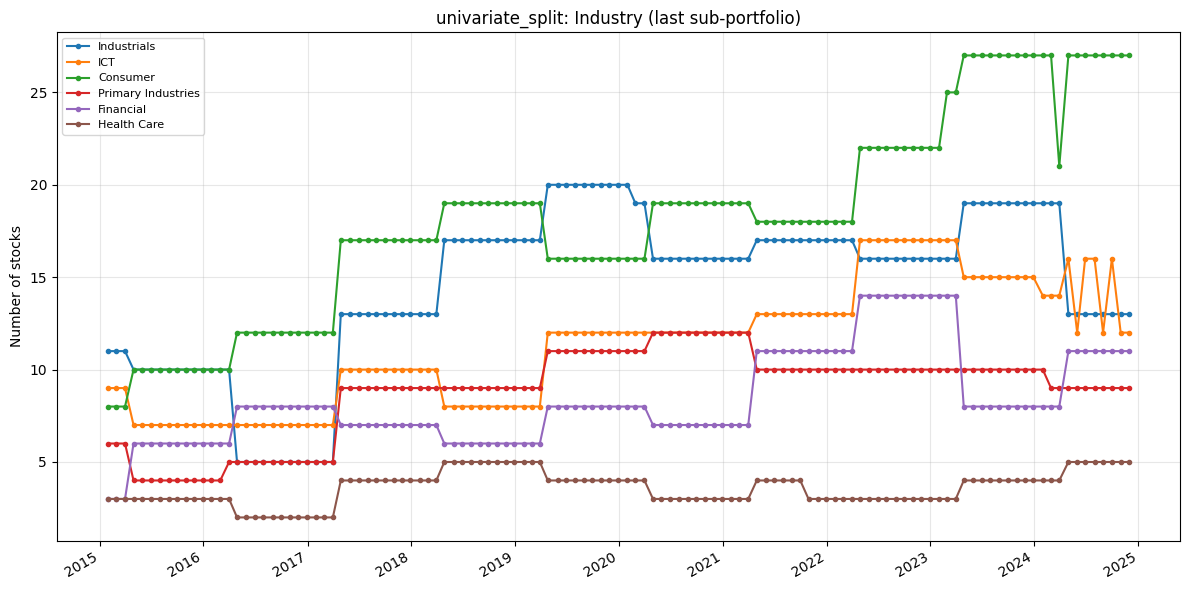

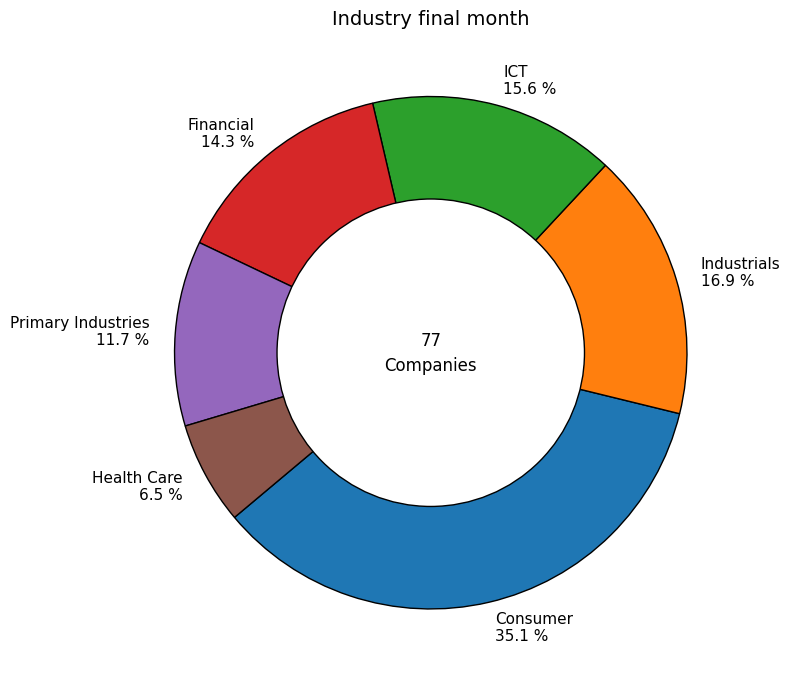

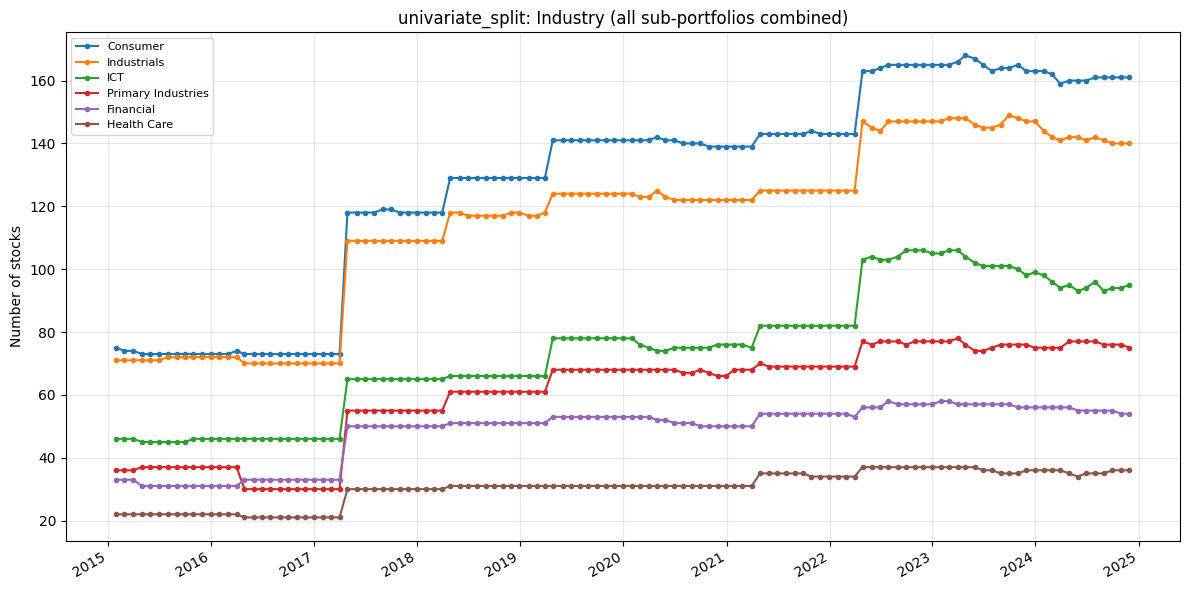

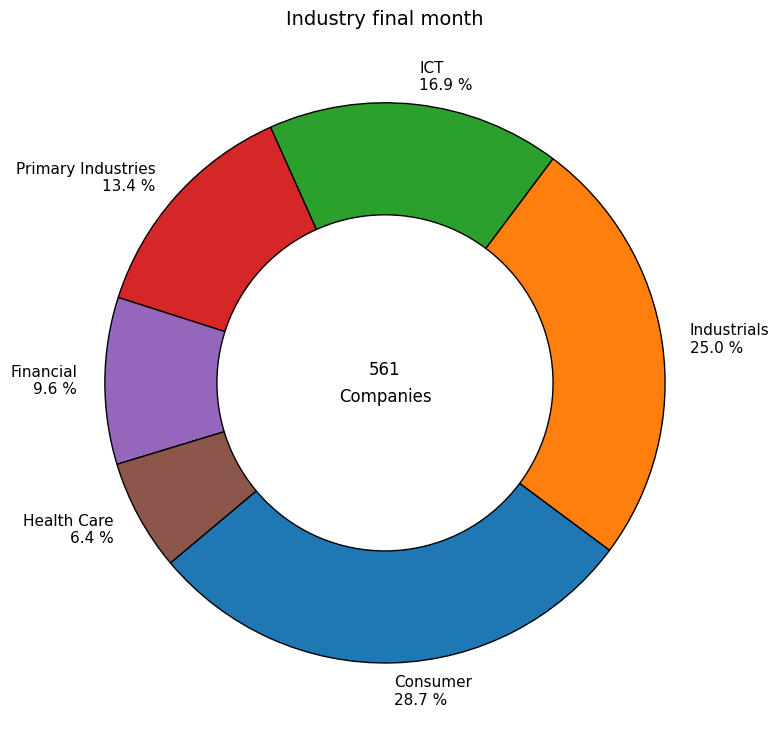

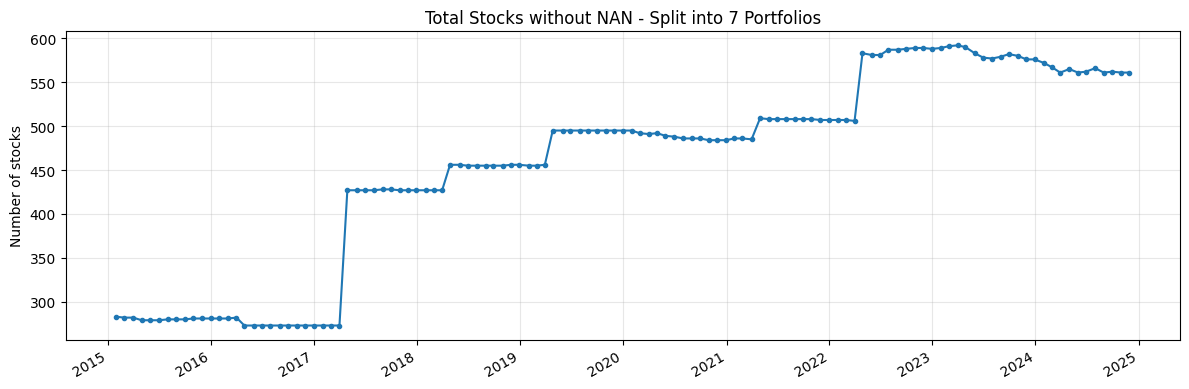

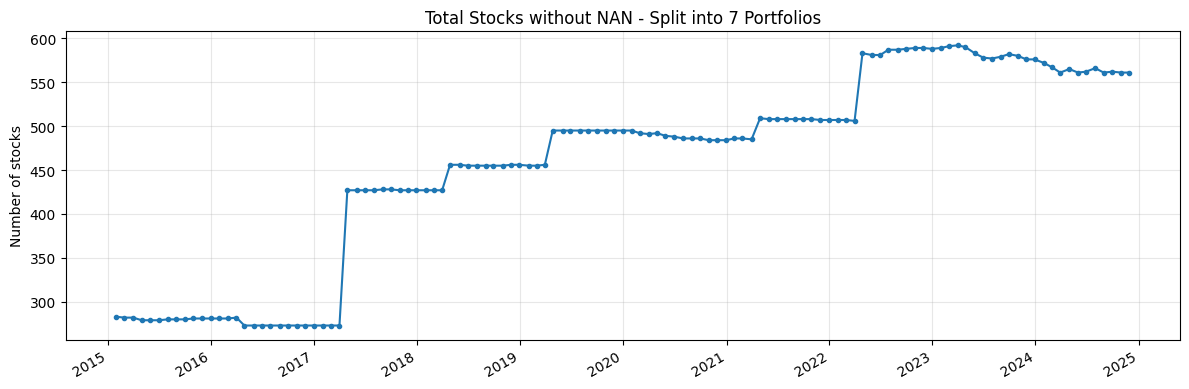

In [ ]:
from IPython.display import display
from functions.portfolio_metrics.Portfolio_Constituents import PortfolioConstituents
import importlib
import functions.output_paths as output_paths_module
importlib.reload(output_paths_module)
from functions.output_paths import output_images_other_dir

# Portfolio constituents inspection: pinned to signal_2 normally; to the chosen ESG
# signal when esg_full_universe (signal_2 does not exist in that mode).
if esg_full_universe:
    _constituents_key = next(iter(universe_signals))   # the single esg_<provider> column
else:
    _constituents_key = "signal_2"
signal_2_simple_quantiles_constituents = signal_quantile_constituents[_constituents_key]

if "start_date" not in globals() or "end_date" not in globals():
    _pc_dates = pd.to_datetime(signal_2_simple_quantiles_constituents.index)
    start_date = str(_pc_dates.min())[:7]
    end_date = str(_pc_dates.max())[:7]

_constituents_img_dir = output_images_other_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)

# esg_full_universe has no LC-derived `loc`/`MacroRegion`, so only break down by Industry.
_pc_cat_cols = ["Industry"] if esg_full_universe else ["Industry", "loc"]
_pc_pie_cols = ["Industry"] if esg_full_universe else ["Industry", "loc", "MacroRegion"]




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(category_over_time_cols=_pc_cat_cols, pie_cols=_pc_pie_cols,
                  save=True, show=True, out_dir=str(_constituents_img_dir))

# Options:
pc2.run_all_plots(
    category_over_time_cols=_pc_cat_cols, pie_cols=_pc_pie_cols,
    analyse_all_portfolios_at_once=True, save=True, show=True, out_dir=str(_constituents_img_dir)
)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)
# Plot (like your snippet)
pc2.total_stocks_over_time(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")


In [ ]:
# --- ESG portfolio holdings over time (what's IN the bucket each month) -------
# Simple knob: which quantile bucket to inspect.
#   0 = lowest-signal bucket ... (no_simple_quantiles - 1) = highest = "High ESG"
inspect_portfolio_key = no_simple_quantiles - 1   # <-- change to inspect a different bucket

_rows = []
for _ms in pc2.constituents:                      # one Series per formation month
    _names = _ms.iloc[inspect_portfolio_key]      # gvkey_iid list in that bucket that month
    for _gi in list(_names):
        _rows.append({
            "date": pd.to_datetime(_ms.name),
            "gvkey_iid": str(_gi),
            "gvkey": str(_gi).split("_")[0],
        })

holdings_over_time = (
    pd.DataFrame(_rows)
    .sort_values(["date", "gvkey_iid"])
    .reset_index(drop=True)
)

print(
    f"Bucket {inspect_portfolio_key} (0=low .. {no_simple_quantiles - 1}=high) | "
    f"{holdings_over_time['date'].nunique()} months | "
    f"{holdings_over_time['gvkey'].nunique()} unique firms"
)
display(holdings_over_time)

# Wide date x firm membership matrix (1 = in the bucket that month), if you want it:
# holdings_matrix = (holdings_over_time.assign(_in=1)
#                    .pivot_table(index="date", columns="gvkey", values="_in", fill_value=0))


Bucket 6 (0=low .. 6=high) | 119 months | 198 unique firms


,date,gvkey_iid,gvkey
0,2015-01-30,005691_01W,005691
1,2015-01-30,006494_01W,006494
2,2015-01-30,009818_01W,009818
3,2015-01-30,015933_01W,015933
4,2015-01-30,017827_01W,017827
...,...,...,...
7707,2024-11-29,279352_01W,279352
7708,2024-11-29,279449_01W,279449
7709,2024-11-29,318510_01W,318510
7710,2024-11-29,319908_01W,319908


In [ ]:
# --- Parameter summary (prints below the cell) ---
from functions.output_paths import RUN_PARAM_NAMES, format_run_parameters

_run_parameters_text = format_run_parameters(globals(), RUN_PARAM_NAMES)
print(_run_parameters_text)


=== Run parameters ===
region_analysis              = 'Japan'
action_characterization      = '4_signals_new'
no_simple_quantiles          = 7
execute_3_filters            = True
golden_data                  = 'v_2C'
signal_denominator           = 'Sum_All_Signals'
esg_choice                   = 'msci'
start_year                   = 2015
end_year                     = 2024
fama_factor_region           = 'Japan'
ff_factors_number            = 5
currency_filter              = ['JPY']
convert_to_USD               = False
drop_real_estate             = True
use_alpha_bound              = True
show_sector_portfolio        = False
industry_level               = 0
min_available_fyears         = 3
top_x_by_industry_even_split = 6
alpha_bound                  = 0.1
mktcap_covered               = 0.95



In [ ]:
# --- Sample coverage diagnostic (isolated in functions/extra_functions/plot_coverage.py) ---
# Plots, over time, how much of the INVESTABLE UNIVERSE our analysis SAMPLE covers:
#   * market-cap coverage (computed in the run's analysis currency; never mixes currencies)
#   * name coverage
# plus a count subplot (sample stocks / names) directly comparable to the
# "Total Stocks without NAN" plot.
#
# EXACT sample: we pass `global_returns` -- the masked date x gvkey_iid analysis panel
# (post LC-intersection, standardization dropna, and cross-signal NaN mask). A listing
# counts in a month iff its cell is non-NaN that month, so the curves and the count
# subplot track the real sample to the listing. Reads already-computed objects only.
plot_coverage = False
if plot_coverage:   
    import importlib
    import functions.extra_functions.plot_coverage as _plot_coverage_module
    importlib.reload(_plot_coverage_module)
    from functions.extra_functions.plot_coverage import plot_universe_coverage_from_regions

    _coverage_save = (_other_img_dir / "sample_coverage_over_time.png") if "_other_img_dir" in globals() else None



    coverage_over_time = plot_universe_coverage_from_regions(
        usa_universe,
        row_universe,
        japan_universe,
        global_returns,             # masked analysis panel (exact non-NaN sample that entered the sorts)
        currency_filter=currency_filter,
        mktcap_covered=mktcap_covered,
        esg_choice=esg_choice,
        convert_to_USD=convert_to_USD,
        region_analysis=region_analysis,
        save_path=_coverage_save,
    )

    display(
        coverage_over_time[
            ["issues_sample", "names_sample", "names_total",
            "mktcap_coverage_pct", "name_coverage_pct"]
        ].describe().round(1)
    )

In [ ]:
# --- ESG coverage diagnostic (gated by show_esg_coverage; skipped under sweep_mode) ---
# % of firm-years with a non-NaN ESG score, per provider, for two samples:
#   row 1 = raw-LC signal-active firm-years (loc == 'JPN'), BEFORE sample filters
#   row 2 = post-filter stock-fiscal-years actually traded in global_returns
# Note: S&P attaches as-of the trading date (merge_asof); MSCI/Refinitiv attach by
# fiscal year (last_year) -- directionally comparable, not identical temporal footing.
#
# The pipeline only merges the ONE provider chosen by esg_choice, so we build a
# diagnostic-only copy of the universes carrying ALL THREE provider columns via
# merge_all_esg_to_universe (this does not touch the universes used by the pipeline).




# Note ESG is matched on "Last_Year" using the year_split_month
if show_esg_coverage and not globals().get("sweep_mode", False):
    from functions.data_functions.get_data import merge_all_esg_to_universe
    _usa_cov, _row_cov, _jpn_cov = merge_all_esg_to_universe(
        usa_universe, row_universe, japan_universe, msci_score_column=msci_score_column
    )
    esg_lookup = build_esg_lookup(_usa_cov, _row_cov, _jpn_cov)
    cov1 = coverage_sample1_lc(lc_raw_for_coverage, esg_lookup, categories_dict, signal_denominator)
    cov2 = coverage_sample2_returns(global_returns, prep.global_universe, esg_lookup)
    esg_coverage_table_df = esg_coverage_table(cov1, cov2)
    display(esg_coverage_table_df)

    # Number of region firms each provider has ESG data for, per fiscal year
    firms_with_esg_data_df = firms_with_esg_data_by_year(japan_universe, msci_score_column=msci_score_column)
    print("Number of firms with ESG data")
    display(firms_with_esg_data_df)
